# 2025 02 18 - Marco mappings

In this notebook, we attempt to understand the result of the mapping of sequence reads against a database of plant-associated bacteria.

In [155]:
import pysam
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

Whatever we do, we must comply with Marco's pipeline.


    1) la obtención de al menos una coincidencia con la base de datos, 2) con una longitud mayor o igual a 125 nt y 3) con una cobertura igual a 100%. En la segunda etapa se eliminaron las lecturas para las que se obtuvo una coincidencia con más de una secuencia de referencia, así como las lecturas para las que no se obtuvo una coincidencia con la misma secuencia de referencia en ambos sentidos de secuenciación. La última etapa consistió en la eliminación de las lecturas asignadas a una referencia con una cobertura genómica menor del 1%.

## Step 1: Reading SAM files

We will use pysam to read these bulky files.

In [156]:
def from_sam_to_df(filepath, library_name):
    samfile = pysam.AlignmentFile(filepath, "r")
    records = []
    for read in samfile.fetch():
        if read.is_paired:
            records.append(read.to_dict())
    # records = list(map(lambda x: x.to_dict(), samfile.fetch()))
    df = pd.DataFrame.from_records(records)
    df['library_name'] = library_name
    df['ref_name'] = df['ref_name'].astype(int)
    df['map_quality'] = df['map_quality'].astype(int)
    df['length'] = df['length'].astype(int)
    return df

In [157]:
u = from_sam_to_df("/data/MIRIPVIR25/matches/PV051_22518_ACTTGA.hits.sam", "PV051_25518")


In [158]:
with open('/data/MIRIPVIR25/reference_genomes/.genome-index', 'r') as f:
    species = [x.strip()[1:] for x in f.readlines()]
len(species)
u['match'] = u['ref_name'].map(lambda x: species[x])
u['refid'] = u['match'].apply(lambda x: x.split(' ')[0])
u

,name,flag,ref_name,ref_pos,map_quality,cigar,next_ref_name,next_ref_pos,length,seq,qual,tags,library_name,match,refid
0,J00148:55:HN7NMBBXX:5:1101:25053:3829,73,2956,615,60,49S102M,*,0,0,AGGGTCCTGAACTTCTTTTCCCAGAGAAGAAGCAATGACGGTATCT...,AAFFFJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJAJJFJJJJ...,"[NH:i:1, AS:i:102, NM:i:0]",PV051_25518,NZ_JABUOH010000044.1 Candidatus Phytoplasma pr...,NZ_JABUOH010000044.1
1,J00148:55:HN7NMBBXX:5:1101:9587:4215,89,2648,3378,60,151M,*,0,0,GCCCCCAACTTTCGTTCTTGATTAATGAAAACATCCTTGGCAAATG...,AAFFFJJJJJJJJJJJ7JJJJJJJJJJJJJJJJJJJJF<JJJJJ<J...,"[NH:i:1, AS:i:151, NM:i:0]",PV051_25518,NZ_MSPX01000036.1 Xaviernesmea rhizosphaerae s...,NZ_MSPX01000036.1
2,J00148:55:HN7NMBBXX:5:1101:3701:4286,137,2956,352,60,56S95M,*,0,0,CTGGAAACGGCTGCTAATACCCCGTAAGCTGAGGAGCAAAAGGAGG...,AAFFFJJJJJJJJJJFJJJJJJJFJJJJJJJJ<JJJJJFJFJJJJJ...,"[NH:i:1, AS:i:95, NM:i:0]",PV051_25518,NZ_JABUOH010000044.1 Candidatus Phytoplasma pr...,NZ_JABUOH010000044.1
3,J00148:55:HN7NMBBXX:5:1101:18893:4338,153,2648,925,60,151M,*,0,0,ACCAGCTACTAGACGGTTCGATTAGTCTTTCGCCCCTATACCCAAG...,AAFFFJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJ...,"[NH:i:1, AS:i:151, NM:i:0]",PV051_25518,NZ_MSPX01000036.1 Xaviernesmea rhizosphaerae s...,NZ_MSPX01000036.1
4,J00148:55:HN7NMBBXX:5:1101:26717:4356,89,2648,3013,60,42S109M,*,0,0,CATAGTCCCTCTAAGAAGCCGGCCGTGAAGGGATGCCTCCACGTAG...,AAFFFJJJJJJJJJJJFJJJJJJJJJJJJJJJJJJ7J<JJJJJJ-F...,"[NH:i:1, AS:i:109, NM:i:0]",PV051_25518,NZ_MSPX01000036.1 Xaviernesmea rhizosphaerae s...,NZ_MSPX01000036.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18952,J00148:55:HN7NMBBXX:5:2228:20344:1578,153,2648,8219,60,151M,*,0,0,TGGGTGAACAATCCAACACTTGGTGAATTCTGCTTCACAATGATAG...,AAFFFFJJJJJJJJJFJJJJJFJJJJJJJJJJJJJJJJJJJJJJJJ...,"[NH:i:1, AS:i:151, NM:i:0]",PV051_25518,NZ_MSPX01000036.1 Xaviernesmea rhizosphaerae s...,NZ_MSPX01000036.1
18953,J00148:55:HN7NMBBXX:5:2228:27387:1613,137,2648,3372,60,151M,*,0,0,CTTCGAGCCCCCAACTTTCGTTCTTGATTAATGAAAACATCCTTGG...,AAFFFJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJ...,"[NH:i:1, AS:i:151, NM:i:0]",PV051_25518,NZ_MSPX01000036.1 Xaviernesmea rhizosphaerae s...,NZ_MSPX01000036.1
18954,J00148:55:HN7NMBBXX:5:2228:8197:1842,99,2956,4369,60,146M5S,=,4369,146,CCTCGATGTCGGCTCTTCGCCACCTGGGGCTGTAGTATGTTCCAAG...,AAFFFJJJJJJJJJJJJFJJFFJJFJJJJJ<FJJJJJFJJJFJJJJ...,"[NH:i:1, AS:i:146, NM:i:0]",PV051_25518,NZ_JABUOH010000044.1 Candidatus Phytoplasma pr...,NZ_JABUOH010000044.1
18955,J00148:55:HN7NMBBXX:5:2228:8197:1842,147,2956,4369,60,5S146M,=,4369,-146,GATCTCCTCGATGTCGGCTCTTCGCCACCTGGGGCTGTAGTATGTT...,AAFFFJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJJ...,"[NH:i:1, AS:i:146, NM:i:0]",PV051_25518,NZ_JABUOH010000044.1 Candidatus Phytoplasma pr...,NZ_JABUOH010000044.1


## Step 2: Filtering out reads

In this step, we will attempt to remove all the reads that are not matching at least 125bp, and all those that have any insertion or deletion. We will also remove all the squences that have low quality

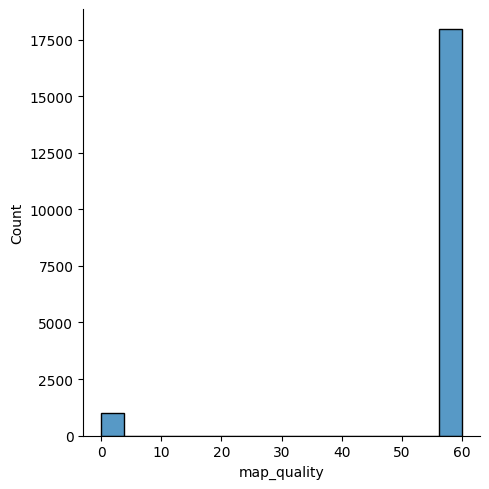

In [82]:
sns.displot(x='map_quality',data=u)

We use the cigar codes to establish our alignment criteria

In [83]:
def extract_from_cigar(x, flag):
    try:
        u = re.search('(\d+)' + flag, x).group(1).replace(flag, '')
    except AttributeError:
        return 0
    return int(u)
extract_from_cigar('1234M123I', 'M')

1234

In [84]:

u['n_matches'] = u['cigar'].apply(lambda x: extract_from_cigar(x, 'M'))
u['n_insertions'] = u['cigar'].apply(lambda x: extract_from_cigar(x, 'I'))
u['n_deletions'] = u['cigar'].apply(lambda x: extract_from_cigar(x, 'D'))
u['n_substitutions'] = u['cigar'].apply(lambda x: extract_from_cigar(x, 'S'))

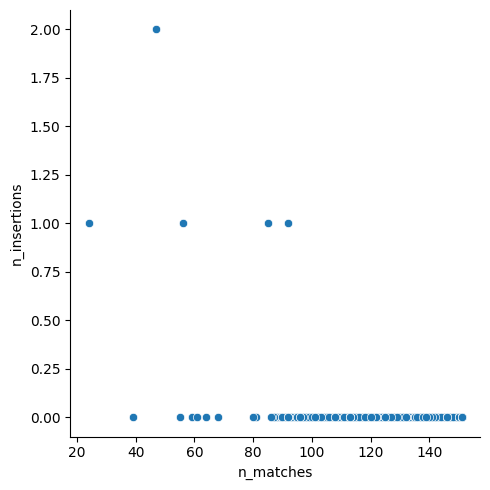

In [69]:
sns.relplot(data=u, x='n_matches', y='n_insertions')

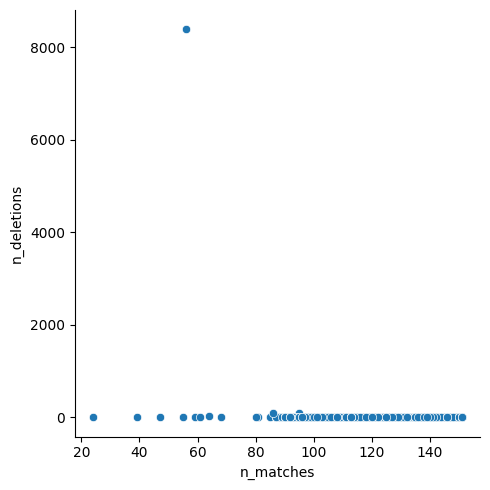

In [70]:
sns.relplot(data=u, x='n_matches', y='n_deletions')

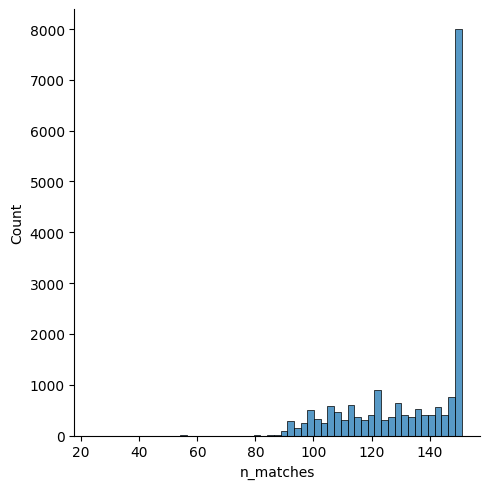

In [71]:
sns.displot(data=u, x='n_matches')

We apply our filter here

In [85]:
u = u.query('n_matches > 125 and n_insertions == 0 and n_deletions == 0 and n_substitutions == 0 and map_quality >= 60')

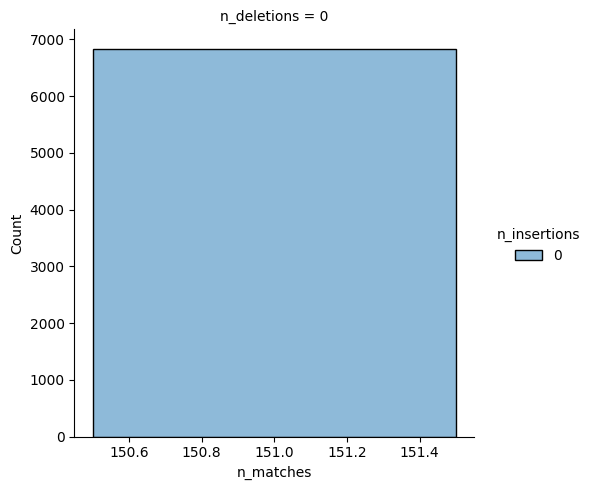

In [86]:
sns.displot(data=u, x='n_matches', hue='n_insertions', col='n_deletions')

## Step 3: Reference sequences

In this step, we will remove the reads that matched different references, as it means that they are ambiguous.

In [102]:
u.groupby(
    ['name', 'refid'], as_index=False
).size().value_counts(subset=['name'], sort=True).reset_index()['count'].unique()

array([1])

It seems there are no such cases

## Step 4: Genome coverage

In [159]:
u['ref_pos'] = u['ref_pos'].astype(int)
u['log_ref_pos'] = u['ref_pos'].apply(np.log10)

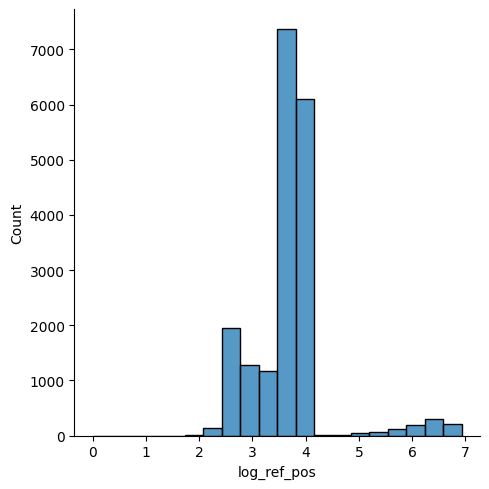

In [160]:
sns.displot(data=u, x='log_ref_pos', bins=20)

In [161]:
from Bio import SeqIO

In [162]:
genomes = list(SeqIO.parse("/data/MIRIPVIR25/reference_genomes/genomes.fa", format='fasta'))
genome_lengths = [dict(id=x.id, length=len(x.seq)) for x in genomes]
genome_lengths = pd.DataFrame.from_records(genome_lengths)
genome_lengths['loglength'] = genome_lengths['length'].apply(np.log10)

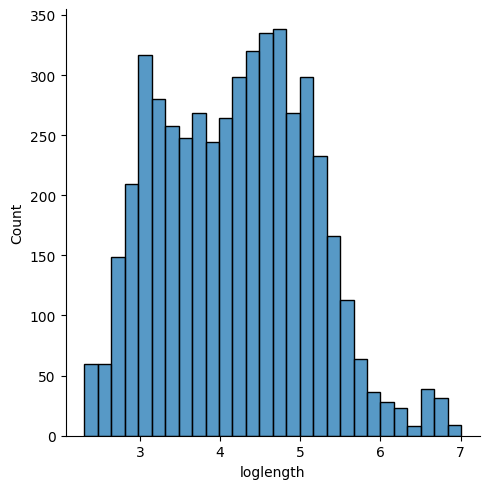

In [163]:
g = sns.displot(data=genome_lengths, x='loglength')

In [154]:
genome_lengths.query('loglength > 5.0')

,id,length,loglength
0,NC_004578.1,6397126,6.805985
3,NC_009937.1,5369772,6.729956
4,NC_011989.1,3726375,6.571287
5,NC_011988.1,1283187,6.108290
7,NC_011991.1,130435,5.115394
...,...,...,...
4949,NZ_FTPD01000010.1,186496,5.270670
4958,NZ_FTPD01000045.1,758168,5.879765
4959,NZ_LT853882.1,4272102,6.630642
4962,NZ_LT855380.1,6093513,6.784868
